In [1]:
from dataclasses import dataclass
import numpy as np
import mediapy as media
from pathlib import Path
import enum
from tqdm import tqdm
import mujoco
from scipy.spatial.transform import Rotation as R
from scipy.ndimage import gaussian_filter1d
from scipy.optimize import minimize
from tqdm import tqdm
import enum

## Helper methods

In [2]:
class Resolution(enum.Enum):
  SD = (480, 640)
  HD = (720, 1280)
  UHD = (2160, 3840)


def quartic(t: float) -> float:
  return 0 if abs(t) > 1 else (1 - t**2) ** 2


def blend_coef(t: float, duration: float, std: float) -> float:
  normalised_time = 2 * t / duration - 1
  return quartic(normalised_time / std)


def unit_smooth(normalised_time: float) -> float:
  return 1 - np.cos(normalised_time * 2 * np.pi)


def azimuth(
    time: float, duration: float, total_rotation: float, offset: float
) -> float:
  return offset + unit_smooth(time / duration) * total_rotation

## Parameters

In [3]:
res = Resolution.SD
fps = 40
duration = 10.0
ctrl_rate = 2
ctrl_std = 0.05
total_rot = 60
blend_std = .8
h, w = res.value

## Loading and rendering the model

In [4]:
model_dir = Path("universal_robots_ur10e")
model_xml = model_dir / "scene_Door.xml"
# Load model.
model = mujoco.MjModel.from_xml_path(str(model_xml))
data = mujoco.MjData(model)

# Make sure offscreen rendering can support the desired resolution.
model.vis.global_.offheight = h
model.vis.global_.offwidth = w

renderer = mujoco.Renderer(model, height=h, width=w)

## Checking for keyframes

""

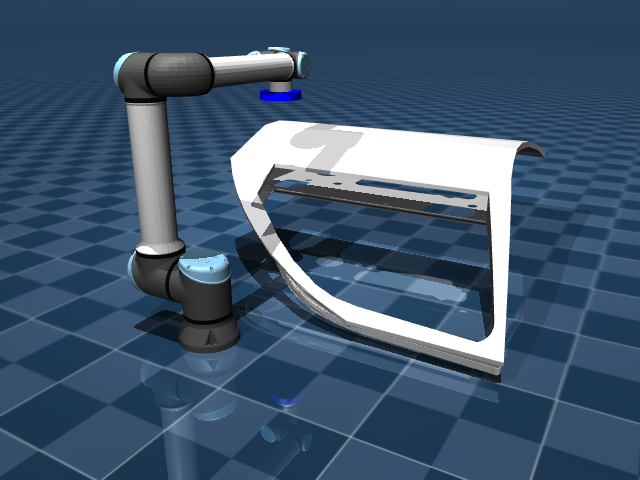

In [5]:
for key in range(model.nkey):
  mujoco.mj_resetDataKeyframe(model, data, key)
  mujoco.mj_forward(model, data)
  renderer.update_scene(data)
  media.show_image(renderer.render())

## Render!

In [6]:
np.random.seed(12345)

timevals = []
angular_velocity = []
q_pos = []
frames = []
eef_forces = []
ee_pos_log = []

trajectory_points = np.loadtxt("Traj2.csv", delimiter=',')

# # Traj 1
# yaw = - 90 - trajectory_points[:, 3] * 180.0 / np.pi
# traj = trajectory_points[:,:3] * 3 / 100.0  # first 190 will be the door front
# traj[:,1] += 1.0
# traj[:,2] += 0.43
# total_frames = len(traj)

# Traj 2
yaw = - 90 + trajectory_points[:, 3] * 180.0 / np.pi
traj = trajectory_points[:,:3] * 3 / 100.0  # first 190 will be the door front
traj[:,0] += 0.1
traj[:,1] += 0.85
traj[:,2] += 0.45
total_frames = len(traj)

# Smooth the trajectory
traj = gaussian_filter1d(traj, sigma=2, axis=0)
yaw = gaussian_filter1d(yaw, sigma=2, axis=0)
# Rendering options for visual and collision geometries
vis = mujoco.MjvOption()
vis.geomgroup[2] = True
vis.geomgroup[3] = False
coll = mujoco.MjvOption()
coll.geomgroup[2] = False
coll.geomgroup[3] = True
coll.flags[mujoco.mjtVisFlag.mjVIS_CONVEXHULL] = True

# Create a camera that will revolve around the robot
camera = mujoco.MjvCamera()
mujoco.mjv_defaultFreeCamera(model, camera)
camera.distance = 2
camera.elevation = -10
camera.lookat[:] = [0.5, 0.5, 0.4]

eef_force_id = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_SENSOR, "eef_force")

def compute_inverse_kinematics(model, data, target_pos, target_quat):
    """Compute inverse kinematics with position + orientation."""
    # target_quat = np.asarray(target_quat).flatten()
    def objective(q):
        data.qpos[:] = q
        mujoco.mj_forward(model, data)
        ee_pos = data.xpos[ee_site_id]
        ee_quat = data.xquat[ee_site_id]
        pos_error = np.linalg.norm(ee_pos - target_pos)
        quat_error = 1 - np.dot(ee_quat, target_quat)**2
        return pos_error + 0.5 * quat_error  # Adjust weight if needed
    


    bounds = [(model.jnt_range[j, 0], model.jnt_range[j, 1]) for j in range(model.nq)]
    result = minimize(objective, data.qpos.copy(), bounds=bounds, method="SLSQP")
    return result.x if result.success else None



# Get end-effector site ID
ee_site_id = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_SITE, "ee_site")

# Iterate through trajectory points
for i, point in tqdm(enumerate(traj[:total_frames]), total=total_frames, desc="Rendering frames"):
    target_quat = R.from_euler('z', yaw[i], degrees=True).as_quat()
    q_desired = compute_inverse_kinematics(model, data, traj[i],target_quat)# point)
    if q_desired is not None:
        data.qpos[:] = q_desired
        mujoco.mj_forward(model, data)

        timevals.append(data.time)
        # print(f"Frame {i}: Time {data.time:.2f}, Position {point}, Qpos {data.qpos}")
        
        # data logging
        angular_velocity.append(data.qvel.copy())
        q_pos.append(data.qpos.copy())
        eef_forces.append(data.sensordata[model.sensor_adr[eef_force_id] : model.sensor_adr[eef_force_id] + 3].copy())
        
        ee_pos_log.append(data.xpos[ee_site_id].copy())

        # Adjust camera azimuth dynamically
        camera.azimuth += total_rot / total_frames

        # Render frame
        renderer.update_scene(data, camera, scene_option=vis)
        frame = renderer.render().copy().astype(np.uint8)
        frames.append(frame)
        mujoco.mj_step(model, data)  # update simulation state and time

# Display video
media.show_video(frames, fps=fps, loop=False)

Rendering frames: 100%|██████████| 416/416 [00:36<00:00, 11.49it/s]


This browser does not support the video tag.


## Plots

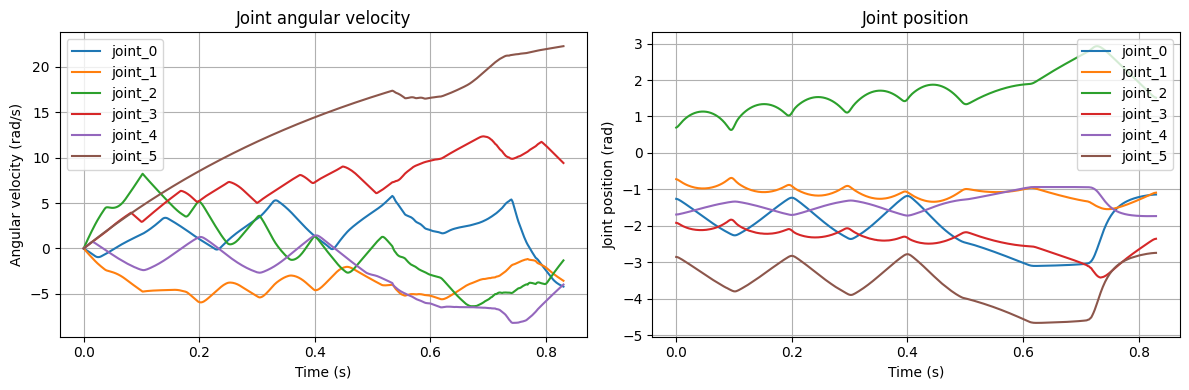

In [7]:
import matplotlib.pyplot as plt
_,ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(timevals, angular_velocity)
ax[0].set_xlabel("Time (s)")
ax[0].set_ylabel("Angular velocity (rad/s)")
ax[0].set_title("Joint angular velocity")
ax[0].legend(['joint_' + str(i) for i in range(model.nv)])
ax[0].grid()
ax[1].plot(timevals, q_pos)
ax[1].set_xlabel("Time (s)")
ax[1].set_ylabel("Joint position (rad)")
ax[1].set_title("Joint position")
ax[1].legend(['joint_' + str(i) for i in range(model.nv)])
ax[1].grid()

plt.tight_layout()
plt.show()

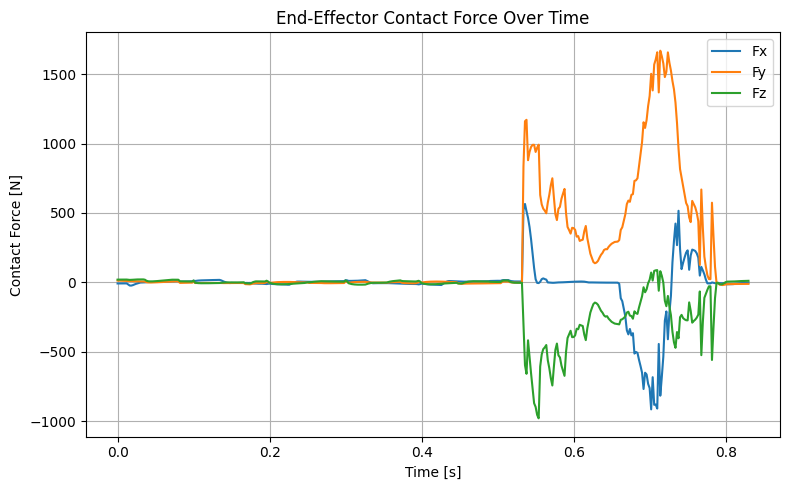

In [8]:
eef_forces = np.array(eef_forces)
timevals = np.array(timevals)

plt.figure(figsize=(8, 5))
plt.plot(timevals, eef_forces[:, 0], label='Fx')
plt.plot(timevals, eef_forces[:, 1], label='Fy')
plt.plot(timevals, eef_forces[:, 2], label='Fz')
plt.xlabel("Time [s]")
plt.ylabel("Contact Force [N]")
plt.title("End-Effector Contact Force Over Time")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

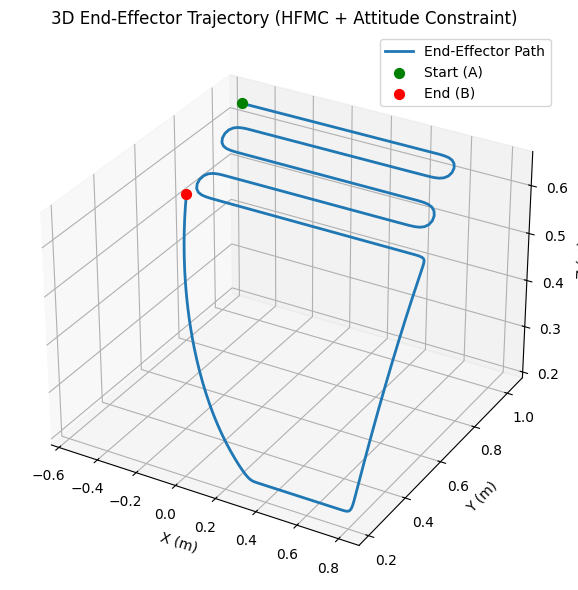

In [9]:
# Convert list to numpy array
pos_array = np.array(ee_pos_log)

# Plot
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot(
    pos_array[:, 0], pos_array[:, 1], pos_array[:, 2],
    label='End-Effector Path', linewidth=2
)
ax.scatter(
    pos_array[0, 0], pos_array[0, 1], pos_array[0, 2],
    color='green', s=50, label='Start (A)'
)
ax.scatter(
    pos_array[-1, 0], pos_array[-1, 1], pos_array[-1, 2],
    color='red', s=50, label='End (B)'
)
ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_zlabel('Z (m)')
ax.set_title('3D End-Effector Trajectory (HFMC + Attitude Constraint)')
ax.legend()
plt.tight_layout()
plt.show()
